In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Customer-Churn-Records.csv')

In [3]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
9377,9378,15709447,Reed,584,France,Female,26,0,146286.22,1,1,0,105105.35,0,0,1,SILVER,256
4796,4797,15765457,Fowler,719,Spain,Male,35,1,100829.94,1,1,1,165008.97,0,0,3,GOLD,657
5840,5841,15729574,Lu,616,Spain,Male,71,4,0.00,2,1,1,173599.38,0,0,5,GOLD,954
9614,9615,15615931,Aitken,746,France,Female,37,4,0.00,2,0,1,171039.56,0,0,5,PLATINUM,219
3719,3720,15577999,Sleeman,850,France,Female,62,1,124678.35,1,1,0,70916.00,1,1,4,GOLD,616


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [5]:
df.dtypes

RowNumber               int64
CustomerId              int64
Surname                object
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

In [8]:
df.select_dtypes(include=['number']).corr()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016140,-0.016957,0.009289,0.002360
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006203,-0.007293,-0.000865,-0.013076
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.026771,-0.027048,-0.012599,0.000077
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285296,0.283530,-0.000876,0.002222
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.013656,-0.013047,0.008663,-0.010196
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118577,0.119124,-0.002588,0.014608
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047611,-0.046357,-0.011394,-0.015330
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.006976,-0.007095,-0.000212,-0.011041
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156356,-0.154741,0.010236,-0.004983
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012490,0.012494,-0.013747,-0.001515


In [9]:
print(df[['Complain', 'Exited']].corr())


          Complain    Exited
Complain  1.000000  0.995693
Exited    0.995693  1.000000


#data leakage from complain col.. 

#dropping cols : Complain, customerid, surname,rownumber..

In [10]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Complain'])

In [11]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,1,DIAMOND,300
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,5,PLATINUM,771
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,3,SILVER,564
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2,GOLD,339


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

#Univariate Analysis

Text(0, 0.5, 'Count')

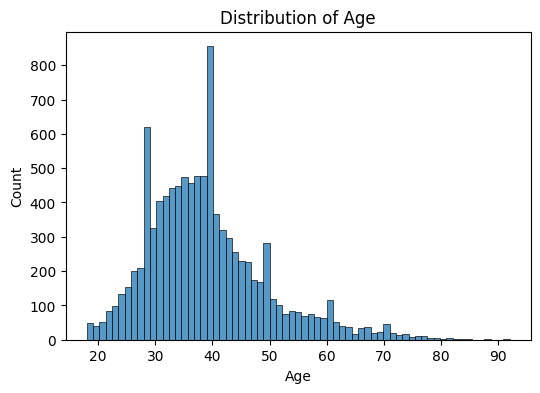

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'])

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

dist is right skewed..

Text(0, 0.5, 'Count')

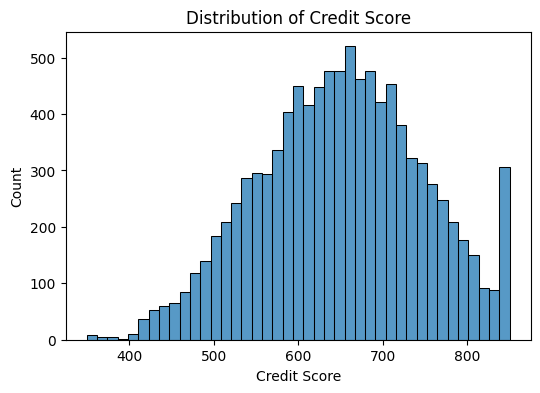

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['CreditScore'])

plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

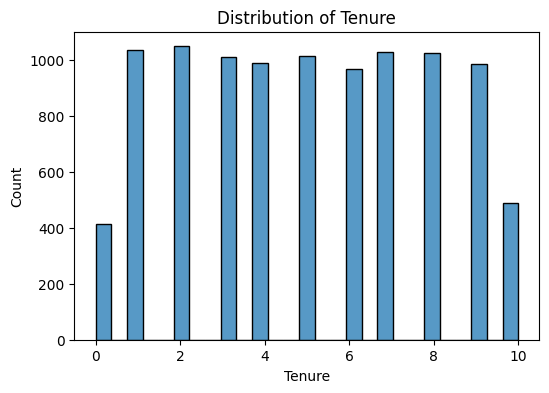

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['Tenure'])

plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

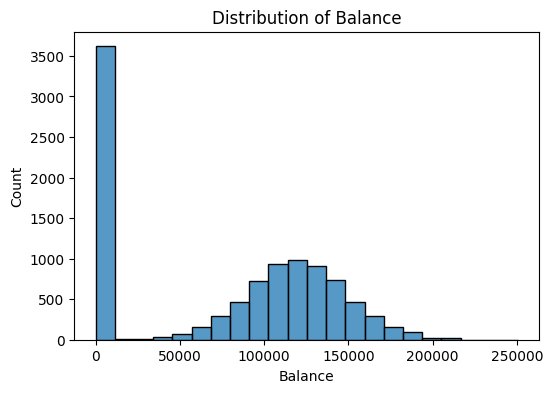

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df['Balance'])

plt.title('Distribution of Balance')
plt.xlabel('Balance')
plt.ylabel('Count')

dist is bimodal..

Text(0, 0.5, 'Count')

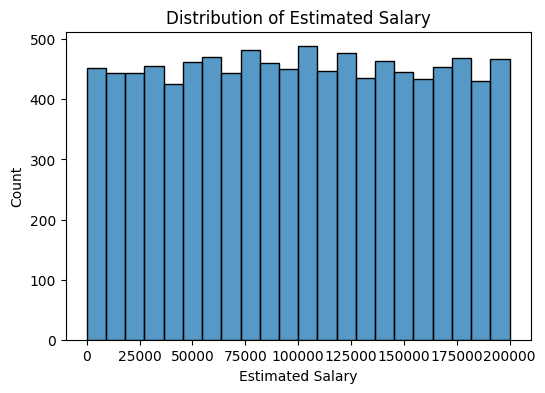

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['EstimatedSalary'])

plt.title('Distribution of Estimated Salary')
plt.xlabel('Estimated Salary')
plt.ylabel('Count')

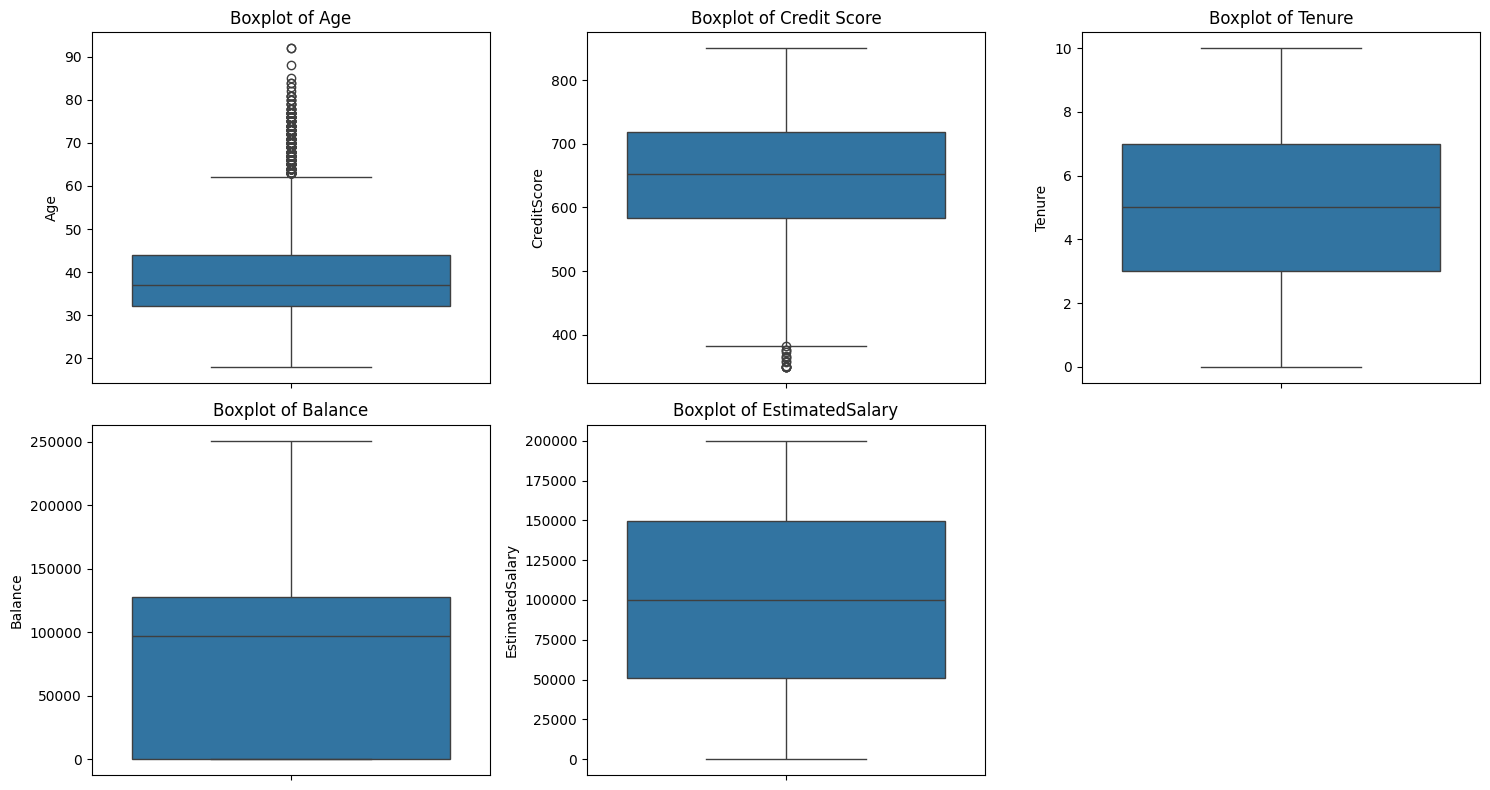

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

sns.boxplot(y=df['Age'], ax=axes[0,0])
axes[0,0].set_title('Boxplot of Age')

sns.boxplot(y=df['CreditScore'], ax=axes[0,1])
axes[0,1].set_title('Boxplot of Credit Score')

sns.boxplot(y=df['Tenure'], ax=axes[0,2])
axes[0,2].set_title('Boxplot of Tenure')

sns.boxplot(y=df['Balance'], ax=axes[1,0])
axes[1,0].set_title('Boxplot of Balance')

sns.boxplot(y=df['EstimatedSalary'], ax=axes[1,1])
axes[1,1].set_title('Boxplot of EstimatedSalary')

axes[1,2].set_visible(False)
plt.tight_layout()
plt.show()

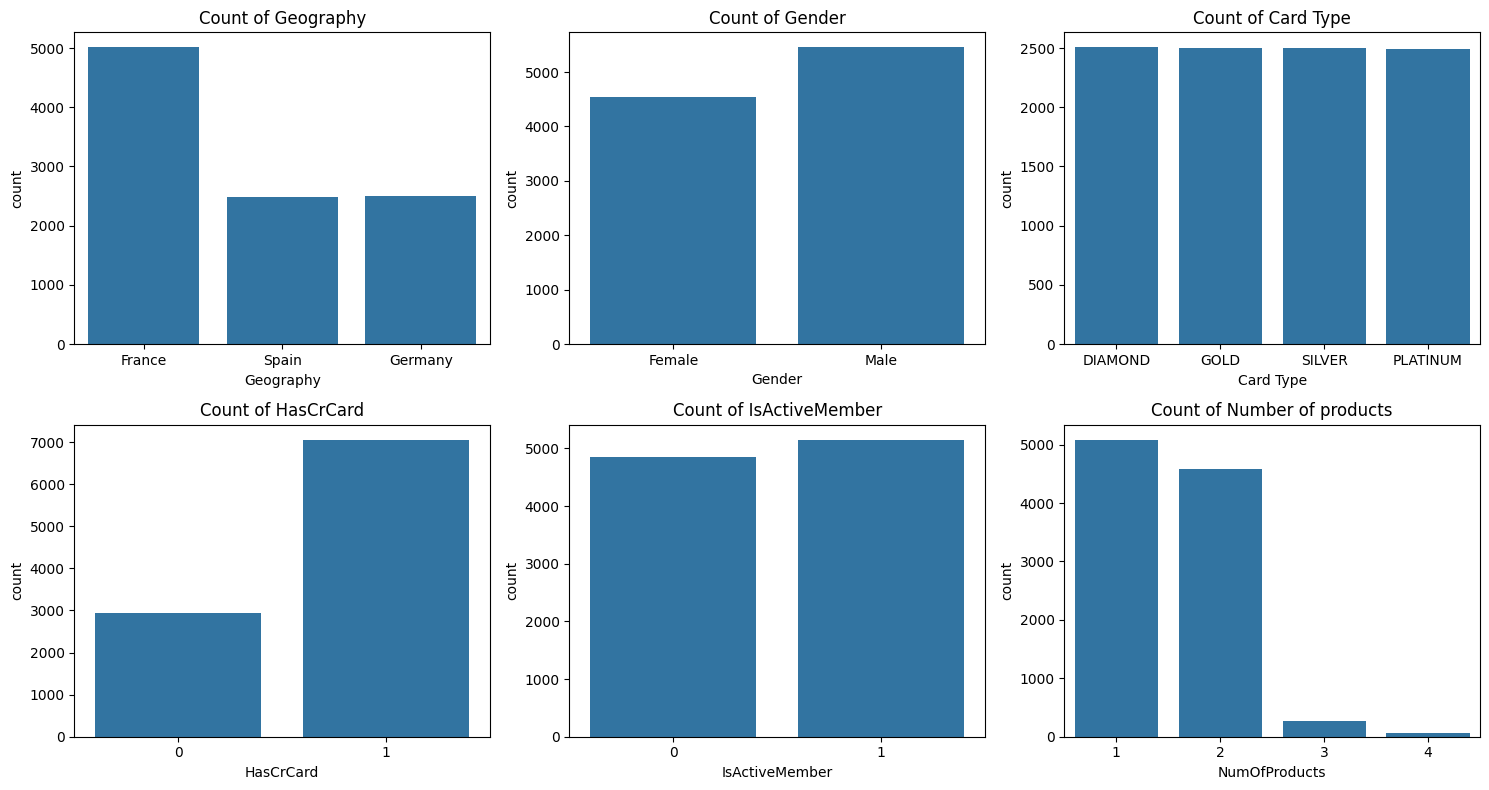

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.countplot(data=df, x='Geography', ax=axes[0,0])
axes[0,0].set_title('Count of Geography')

sns.countplot(data=df, x='Gender', ax=axes[0,1])
axes[0,1].set_title('Count of Gender')

sns.countplot(data=df, x='Card Type', ax=axes[0,2])
axes[0,2].set_title('Count of Card Type')

sns.countplot(data=df, x='HasCrCard', ax=axes[1,0])
axes[1,0].set_title('Count of HasCrCard')

sns.countplot(data=df, x='IsActiveMember', ax=axes[1,1])
axes[1,1].set_title('Count of IsActiveMember')

sns.countplot(data=df, x='NumOfProducts', ax=axes[1,2])
axes[1,2].set_title('Count of Number of products')

plt.tight_layout()
plt.show()

Customers from Germany exhibit the highest churn rate (32.4%), which is nearly double that of France (16.2%) and Spain (16.7%). This suggests that Geography is associated with customer churn and may be an important predictor for the model.

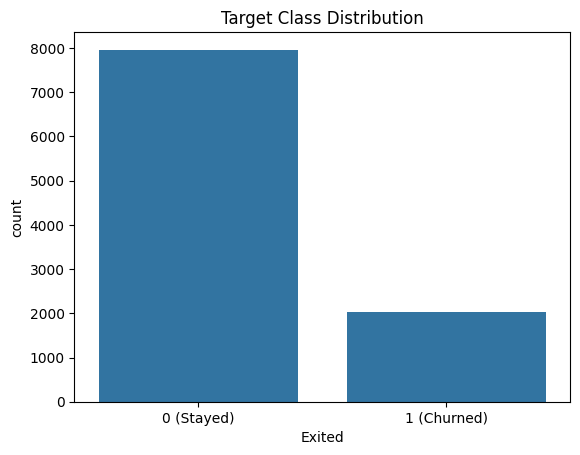

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


In [20]:
sns.countplot(data=df, x='Exited')
plt.xticks([0, 1], ['0 (Stayed)', '1 (Churned)'])
plt.title('Target Class Distribution')
plt.show()

print(df['Exited'].value_counts(normalize=True) * 100)

#Bivariate Analysis

In [21]:
numerical_features=['CreditScore','Age','Tenure','Balance','EstimatedSalary','Point Earned']
## Numerical vs Target Analysis
##This section compares the distribution of numerical features for customers who exited and those who remained. 
##Boxplots are used to visualize differences, while summary statistics help interpret the trends.

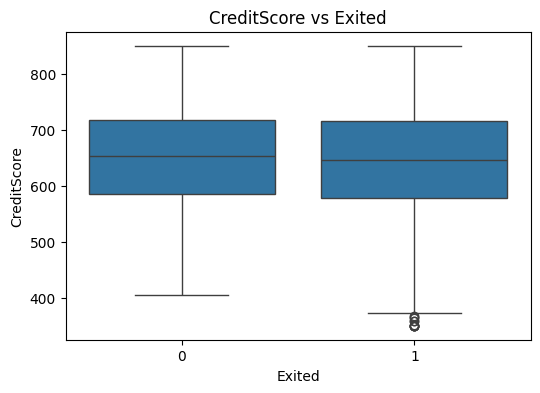

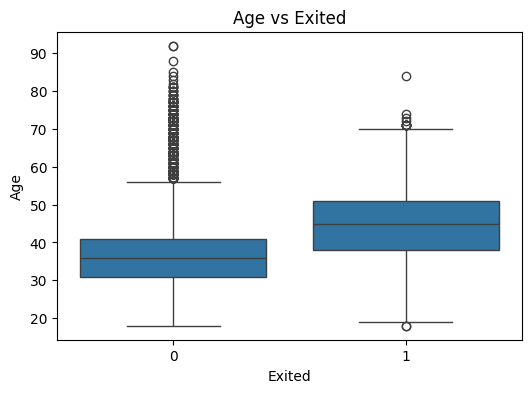

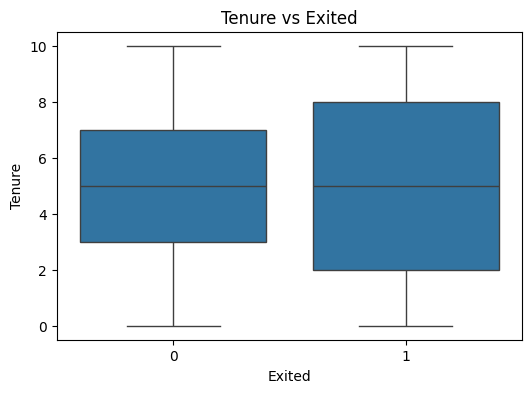

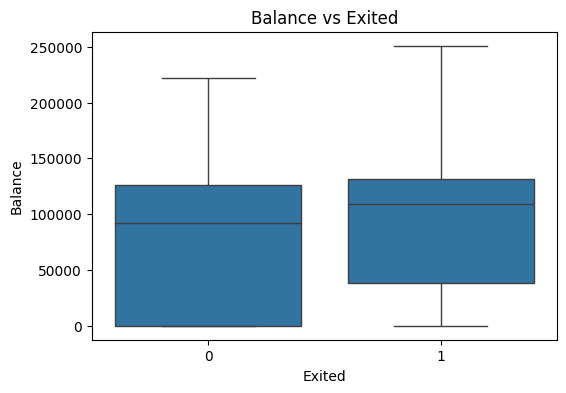

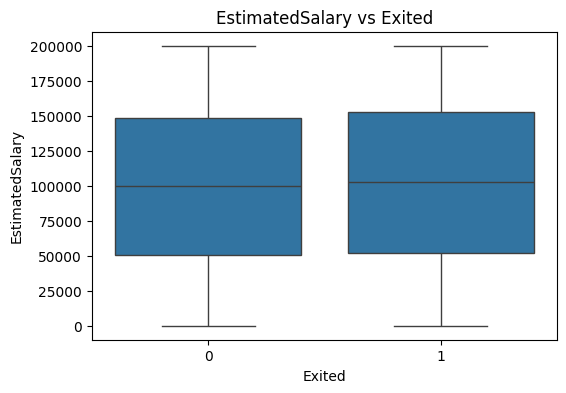

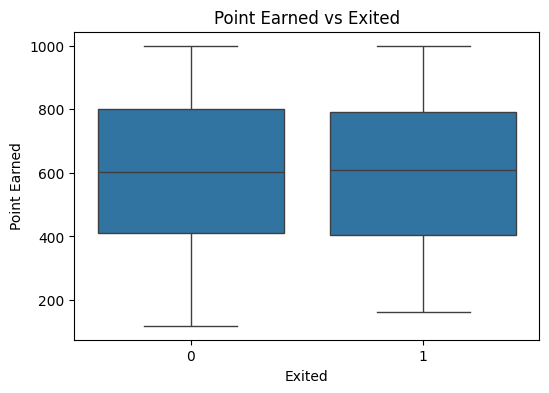

In [22]:
for feature in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='Exited', y=feature)
    plt.title(f'{feature} vs Exited')
    plt.xlabel('Exited')
    plt.ylabel(feature)
    plt.show()

In [23]:
### Mean values for each numerical features
for feature in numerical_features:
    print(f"\n{feature}")
    print(df.groupby('Exited')[feature].mean())


CreditScore
Exited
0    651.837855
1    645.414622
Name: CreditScore, dtype: float64

Age
Exited
0    37.408063
1    44.835623
Name: Age, dtype: float64

Tenure
Exited
0    5.032781
1    4.934740
Name: Tenure, dtype: float64

Balance
Exited
0    72742.750663
1    91109.476006
Name: Balance, dtype: float64

EstimatedSalary
Exited
0     99726.853141
1    101509.908783
Name: EstimatedSalary, dtype: float64

Point Earned
Exited
0    607.044084
1    604.448479
Name: Point Earned, dtype: float64


In [24]:
### Median values for each numerical feature
for feature in numerical_features:
    print(f"\n{feature}")
    print(df.groupby('Exited')[feature].median())


CreditScore
Exited
0    653.0
1    646.0
Name: CreditScore, dtype: float64

Age
Exited
0    36.0
1    45.0
Name: Age, dtype: float64

Tenure
Exited
0    5.0
1    5.0
Name: Tenure, dtype: float64

Balance
Exited
0     92063.06
1    109344.23
Name: Balance, dtype: float64

EstimatedSalary
Exited
0     99620.355
1    102489.335
Name: EstimatedSalary, dtype: float64

Point Earned
Exited
0    603.0
1    610.5
Name: Point Earned, dtype: float64


In [25]:
categorical_features=['Geography','Gender','HasCrCard','IsActiveMember']

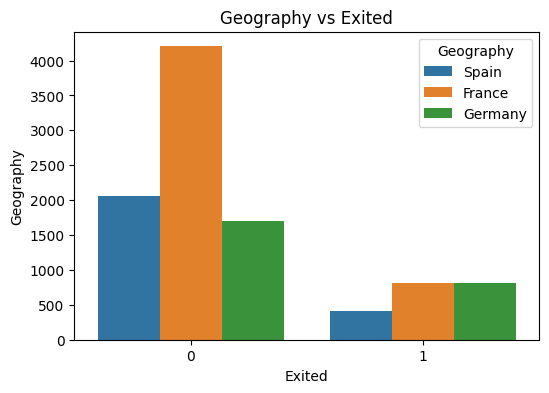

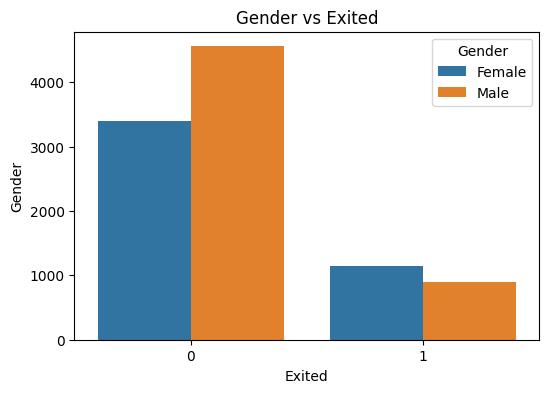

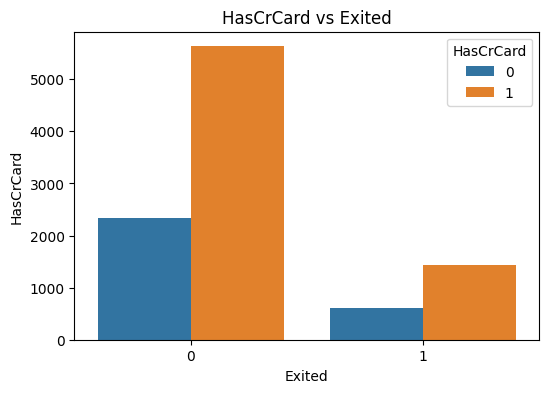

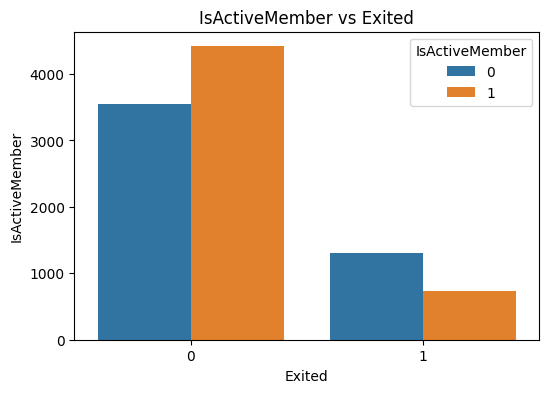

In [26]:
for feature in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='Exited', hue=feature)
    plt.title(f'{feature} vs Exited')
    plt.xlabel('Exited')
    plt.ylabel(feature)
    plt.show()

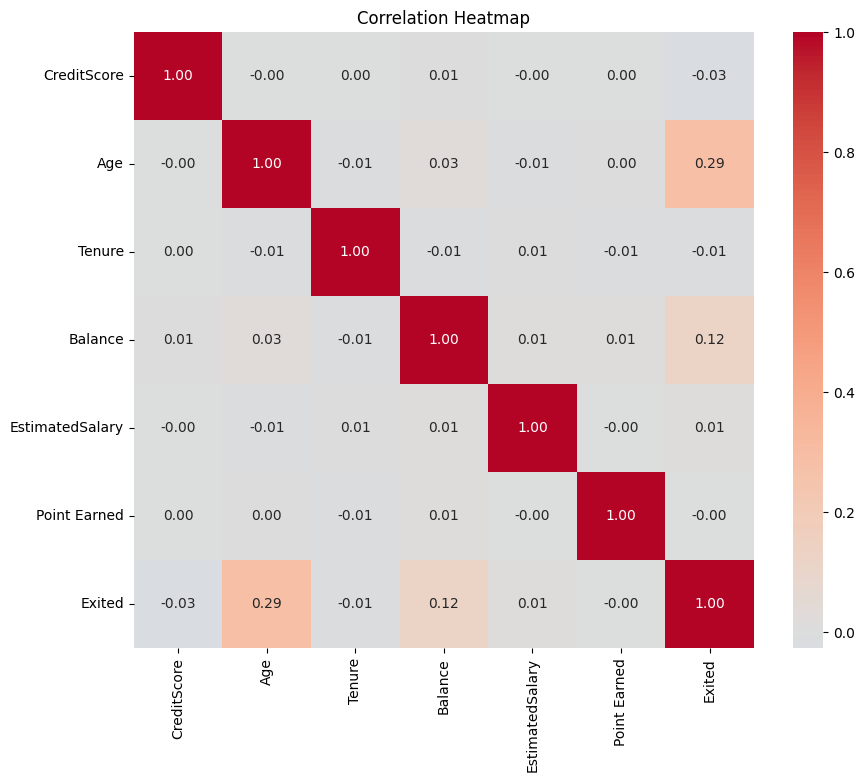

In [27]:
plt.figure(figsize=(10,8))
corr = df[numerical_features + ['Exited']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#
Encoding

In [28]:
print(df['Card Type'].unique())

['DIAMOND' 'GOLD' 'SILVER' 'PLATINUM']


In [29]:
from sklearn.preprocessing import OrdinalEncoder

card_order = ['SILVER', 'GOLD', 'PLATINUM', 'DIAMOND']

oe = OrdinalEncoder(categories=[card_order])
df['Card Type'] = oe.fit_transform(df[['Card Type']])

In [30]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,3.0,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,3.0,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,3.0,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,1.0,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,1.0,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,1,3.0,300
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,5,2.0,771
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,3,0.0,564
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2,1.0,339


In [31]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [32]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned,Geography_Germany,Geography_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,2,3.0,464,False,False
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,3,3.0,456,False,True
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,3,3.0,377,False,False
3,699,Female,39,1,0.00,2,0,0,93826.63,0,5,1.0,350,False,False
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,5,1.0,425,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,Male,39,5,0.00,2,1,0,96270.64,0,1,3.0,300,False,False
9996,516,Male,35,10,57369.61,1,1,1,101699.77,0,5,2.0,771,False,False
9997,709,Female,36,7,0.00,1,0,1,42085.58,1,3,0.0,564,False,False
9998,772,Male,42,3,75075.31,2,1,0,92888.52,1,2,1.0,339,True,False


In [33]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

In [34]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,2,3.0,464,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,3,3.0,456,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,3,3.0,377,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,5,1.0,350,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,5,1.0,425,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1,3.0,300,False,False
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,5,2.0,771,False,False
9997,709,0,36,7,0.00,1,0,1,42085.58,1,3,0.0,564,False,False
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,2,1.0,339,True,False


checking outliers as shown by earlier boxplots

In [35]:
def outlier_detec(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    iqr = Q3-Q1
    lower = Q1 - 1.5*iqr
    upper = Q3 + 1.5*iqr
    outlier = df[(df[col]<lower) | (df[col]>upper)]
    print(f" {col} ")
    print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
    print(f"Number of outliers: {len(outlier)} ({len(outlier)/len(df)*100:.2f}%)")
    return outlier

for col in ['CreditScore', 'Age', 'Balance']:
    outliers = outlier_detec(df, col)
    print()



 CreditScore 
Lower bound: 383.00, Upper bound: 919.00
Number of outliers: 15 (0.15%)

 Age 
Lower bound: 14.00, Upper bound: 62.00
Number of outliers: 359 (3.59%)

 Balance 
Lower bound: -191466.36, Upper bound: 319110.60
Number of outliers: 0 (0.00%)



adding flag for zero balance

In [36]:
df['HasZeroBalance'] = (df['Balance'] == 0).astype(int)

In [37]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned,Geography_Germany,Geography_Spain,HasZeroBalance
0,619,0,42,2,0.00,1,1,1,101348.88,1,2,3.0,464,False,False,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0,3,3.0,456,False,True,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,3,3.0,377,False,False,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,5,1.0,350,False,False,1
4,850,0,43,2,125510.82,1,1,1,79084.10,0,5,1.0,425,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1,3.0,300,False,False,1
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,5,2.0,771,False,False,0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,3,0.0,564,False,False,1
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,2,1.0,339,True,False,0


In [38]:
print(df['HasZeroBalance'].value_counts())
print(df['HasZeroBalance'].value_counts(normalize=True) * 100)

HasZeroBalance
0    6383
1    3617
Name: count, dtype: int64
HasZeroBalance
0    63.83
1    36.17
Name: proportion, dtype: float64


In [39]:
print(df.groupby('HasZeroBalance')['Exited'].mean())

HasZeroBalance
0    0.240953
1    0.138236
Name: Exited, dtype: float64


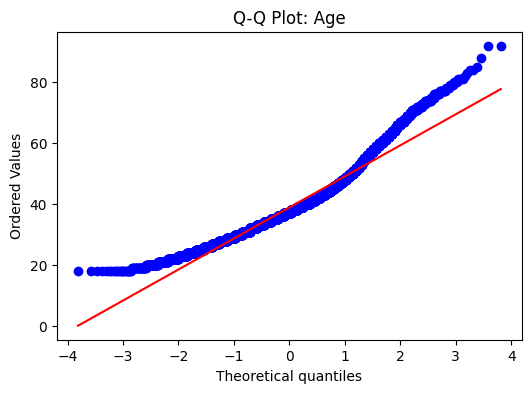

In [40]:
import scipy.stats as stats

plt.figure(figsize=(6,4))
stats.probplot(df['Age'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Age')
plt.show()

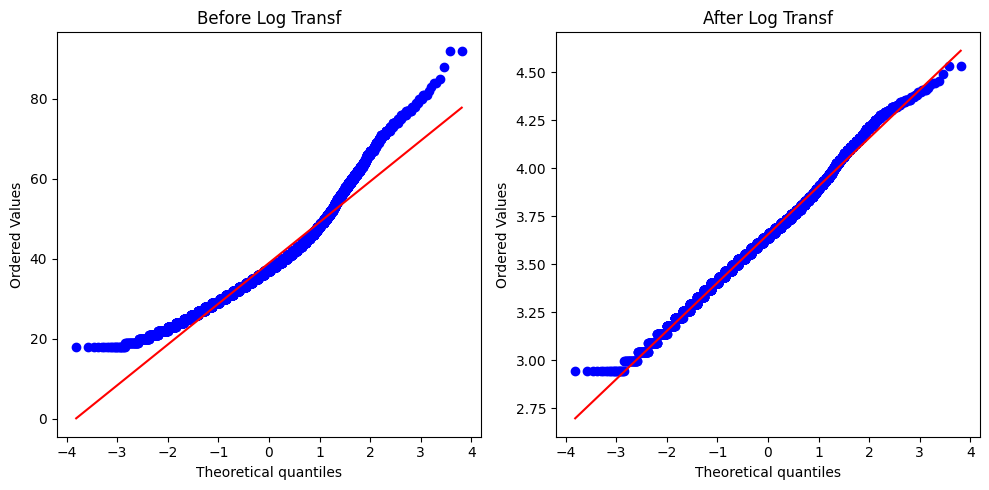

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

stats.probplot(df['Age'], dist="norm", plot=axes[0])
axes[0].set_title('Before Log Transf')

stats.probplot(np.log1p(df['Age']), dist="norm", plot=axes[1])
axes[1].set_title('After Log Transf')

plt.tight_layout()
plt.show()

In [42]:
df['Age'] = np.log1p(df['Age'])


In [43]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned,Geography_Germany,Geography_Spain,HasZeroBalance
0,619,0,3.761200,2,0.00,1,1,1,101348.88,1,2,3.0,464,False,False,1
1,608,0,3.737670,1,83807.86,1,0,1,112542.58,0,3,3.0,456,False,True,0
2,502,0,3.761200,8,159660.80,3,1,0,113931.57,1,3,3.0,377,False,False,0
3,699,0,3.688879,1,0.00,2,0,0,93826.63,0,5,1.0,350,False,False,1
4,850,0,3.784190,2,125510.82,1,1,1,79084.10,0,5,1.0,425,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,3.688879,5,0.00,2,1,0,96270.64,0,1,3.0,300,False,False,1
9996,516,1,3.583519,10,57369.61,1,1,1,101699.77,0,5,2.0,771,False,False,0
9997,709,0,3.610918,7,0.00,1,0,1,42085.58,1,3,0.0,564,False,False,1
9998,772,1,3.761200,3,75075.31,2,1,0,92888.52,1,2,1.0,339,True,False,0


In [44]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=1000)
clf2 = DecisionTreeClassifier(random_state=42)

clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("BASELINE (no scaling)")
print("Accuracy LR:", accuracy_score(y_test, y_pred))
print("Accuracy DT:", accuracy_score(y_test, y_pred1))

BASELINE (no scaling)
Accuracy LR: 0.801
Accuracy DT: 0.7815


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = (lin_reg.predict(X_test) >= 0.5).astype(int)

print("Accuracy Linear Reg (thresholded):", accuracy_score(y_test, y_pred_lin))
print("F1 Linear Reg:", f1_score(y_test, y_pred_lin))

Accuracy Linear Reg (thresholded): 0.8095
F1 Linear Reg: 0.1945031712473573


In [47]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Point Earned']

scaler = StandardScaler()

X_train_final = X_train.copy()
X_test_final = X_test.copy()

X_train_final[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_final[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [48]:
clf_t = LogisticRegression(max_iter=1000)
clf2_t = DecisionTreeClassifier(random_state=42)

clf_t.fit(X_train_final, y_train)
clf2_t.fit(X_train_final, y_train)

y_pred_t = clf_t.predict(X_test_final)
y_pred1_t = clf2_t.predict(X_test_final)

print("AFTER: scaling")
print("Accuracy LR:", accuracy_score(y_test, y_pred_t))
print("Accuracy DT:", accuracy_score(y_test, y_pred1_t))

AFTER: scaling
Accuracy LR: 0.8155
Accuracy DT: 0.7815


In [49]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))


Exited
0    6370
1    1630
Name: count, dtype: int64
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64


In [50]:
from sklearn.metrics import classification_report

clf_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_bal.fit(X_train_final, y_train)
y_pred_bal = clf_bal.predict(X_test_final)

print("LOGISTIC REGRESSION - class_weight='balanced'")
print(classification_report(y_test, y_pred_bal))

LOGISTIC REGRESSION - class_weight='balanced'
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1592
           1       0.38      0.73      0.50       408

    accuracy                           0.71      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.80      0.71      0.73      2000



In [51]:
%pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [53]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [55]:
from xgboost import XGBClassifier

neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
spw = neg / pos
print("scale_pos_weight:", spw)

clf_xgb = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42
)
clf_xgb.fit(X_train_final, y_train)
y_pred_xgb = clf_xgb.predict(X_test_final)

print("XGBOOST - scale_pos_weight applied")
print(classification_report(y_test, y_pred_xgb))

scale_pos_weight: 3.9079754601226995
XGBOOST - scale_pos_weight applied
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1592
           1       0.57      0.65      0.61       408

    accuracy                           0.83      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      0.83      0.83      2000

